In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import h5py
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import CyclicLR
import json
from sklearn.metrics import (classification_report, average_precision_score,
                            confusion_matrix)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/data/"

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preprocessing

### Label

In [ ]:
def load_label_mapping(mapping_path):
    with open(mapping_path, 'r') as f:
        mapping = json.load(f)
    print(f"classes: {mapping['n_classes']}")
    print(f"labels: {list(mapping['label_to_idx'].items())[:]}")
    return mapping

label_mapping = load_label_mapping(BASE_DIR+'label_mapping.json')
n_classes = label_mapping['n_classes']

classes: 15
labels: [('Abies', 0), ('Acer', 1), ('Alnus', 2), ('Betula', 3), ('Cleared', 4), ('Fagus', 5), ('Fraxinus', 6), ('Larix', 7), ('Picea', 8), ('Pinus', 9), ('Populus', 10), ('Prunus', 11), ('Pseudotsuga', 12), ('Quercus', 13), ('Tilia', 14)]


### Augmentation

In [ ]:
class H5Dataset(Dataset):
    def __init__(self, h5_path: str):
        self.h5f = h5py.File(h5_path, 'r')
        self.images = self.h5f['images']
        self.labels = self.h5f['labels']
        self.valid_indices = self._filter_nan_samples()
        self.n_samples = len(self.valid_indices)
        print(f"H5Dataset initialized: {h5_path}")
        print(f"Total samples: {len(self.labels)}")
        print(f"Valid samples: {self.n_samples}")

    def _filter_nan_samples(self):
        valid_indices = []
        for idx in range(len(self.h5f['labels'])):
            img = self.images[idx].astype(np.float32)
            input_bands = img[1:3]  # VV, VH
            if not np.isnan(input_bands).any():
                valid_indices.append(idx)
        return valid_indices

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        img = self.images[actual_idx].astype(np.float32).copy()
        input_bands = img[1:3]  # VV, VH
        label = int(self.labels[actual_idx])

        vv = torch.from_numpy(input_bands[0])  # [H, W]
        vh = torch.from_numpy(input_bands[1])  # [H, W]
        image = torch.stack([vv, vh], dim=0)   # [2, H, W]

        label = torch.tensor(label, dtype=torch.long)
        return image, label

    def get_filename(self, idx):
        actual_idx = self.valid_indices[idx]
        return self.images.file['filenames'][actual_idx].decode('utf-8')

    def get_label_name(self, idx):
        actual_idx = self.valid_indices[idx]
        return self.images.file['label_names'][actual_idx].decode('utf-8')

    def close(self):
        if hasattr(self, 'h5f'):
            self.h5f.close()

    def __del__(self):
        self.close()

In [ ]:
def create_dataloaders(
    train_h5: str,
    test_h5: str,
    batch_size: int = 128,
    num_workers: int = 4,
    val_ratio: float = 0.1
):
    train_dataset = H5Dataset(train_h5)
    test_dataset = H5Dataset(test_h5)

    original_train_size = len(train_dataset)
    val_size = int(original_train_size * val_ratio)
    train_size = original_train_size - val_size

    torch.manual_seed(42)
    train_indices, val_indices = random_split(
        range(original_train_size),
        [train_size, val_size]
    )

    train_subset = torch.utils.data.Subset(train_dataset, train_indices.indices)
    val_dataset = torch.utils.data.Subset(train_dataset, val_indices.indices)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    return train_loader, val_loader, test_loader

In [ ]:
train_loader, val_loader, test_loader = create_dataloaders(
    train_h5=BASE_DIR + 'train_data.h5',
    test_h5=BASE_DIR + 'test_data.h5',
    batch_size=128,
    num_workers=4,
    val_ratio=0.1
)

H5Dataset initialized: /content/drive/MyDrive/data/train_data.h5
Total samples: 45337
Valid samples: 45314
H5Dataset initialized: /content/drive/MyDrive/data/test_data.h5
Total samples: 5044
Valid samples: 5041


### Model

In [ ]:

class TinyResidualBlock(nn.Module):
    """超轻量残差块 - 专为小图像设计"""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        mid_channels = out_channels // 2

        self.conv1 = nn.Conv2d(in_channels, mid_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        self.conv2 = nn.Conv2d(mid_channels, mid_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_channels)

        self.conv3 = nn.Conv2d(mid_channels, out_channels, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out += identity
        out = self.relu(out)

        return out

class SqueezeExcitation(nn.Module):
    """SE注意力模块"""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, _, _ = x.size()
        squeeze = x.view(b, c, -1).mean(dim=2)
        excitation = self.fc1(squeeze)
        excitation = F.relu(excitation, inplace=True)
        excitation = self.fc2(excitation)
        excitation = torch.sigmoid(excitation).view(b, c, 1, 1)
        return x * excitation

class TinyNet(nn.Module):
    """针对6×6小图像优化的CNN"""
    def __init__(self, in_channels=2, num_classes=15, base_channels=32):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True)
        )

        self.layer1 = TinyResidualBlock(base_channels, base_channels*2, stride=1)
        self.se1 = SqueezeExcitation(base_channels*2)

        self.layer2 = TinyResidualBlock(base_channels*2, base_channels*3, stride=1)
        self.se2 = SqueezeExcitation(base_channels*3)

        self.layer3 = TinyResidualBlock(base_channels*3, base_channels*4, stride=1)
        self.se3 = SqueezeExcitation(base_channels*4)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(base_channels*4, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.se1(x)
        x = self.layer2(x)
        x = self.se2(x)
        x = self.layer3(x)
        x = self.se3(x)
        x = self.global_pool(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x

In [ ]:
class ImprovedResidualBlock(nn.Module):
    """PreActivation 残差块 - ResNet V2 风格，梯度更稳定"""

    def __init__(self, in_channels, out_channels, stride=1, dropout=0.2):
        super().__init__()

        # PreActivation: BN → Activation → Conv
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)

        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.activation = nn.GELU()

        # Shortcut
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # PreActivation 风格
        out = self.bn1(x)
        out = self.activation(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.conv2(out)

        # 残差连接（无缩放）
        residual = self.shortcut(x)
        out = out + residual

        return out


class OptimizedCNN(nn.Module):
    """优化后的 CNN - 针对梯度流问题"""

    def __init__(self, in_channels=2, num_classes=15, base_channels=64, dropout=0.3):
        super().__init__()

        # Stem - 减少第一层的学习率（通过初始化）
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_channels, momentum=0.01),
            nn.GELU()
        )

        # 残差块 - 使用改进版本
        self.layer1 = ImprovedResidualBlock(
            base_channels, base_channels*2,
            stride=1, dropout=dropout
        )

        self.layer2 = ImprovedResidualBlock(
            base_channels*2, base_channels*4,
            stride=2, dropout=dropout # ← 降低 stride 层的 dropout
        )

        self.layer3 = ImprovedResidualBlock(
            base_channels*4, base_channels*8,
            stride=1, dropout=dropout # ← 深层更少 dropout
        )

        # 全局池化 - 简化（去掉额外卷积）
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        # 分类器 - 增强学习能力
        self.classifier = nn.Sequential(
            nn.Linear(base_channels*8, base_channels*4),  # ← 增加中间层宽度
            nn.BatchNorm1d(base_channels*4, momentum=0.01),
            nn.GELU(),
            nn.Dropout(dropout * 1.2),

            nn.Linear(base_channels*4, base_channels*2),
            nn.BatchNorm1d(base_channels*2, momentum=0.01),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(base_channels*2, num_classes)
        )

        # 初始化
        self._initialize_weights()

    def _initialize_weights(self):
        """改进的权重初始化"""
        for name, m in self.named_modules():
            if isinstance(m, nn.Conv2d):
                # Stem 使用较小的初始化
                if 'stem' in name:
                    nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                    m.weight.data *= 0.5  # ← 减少第一层初始权重
                else:
                    nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


# 新段落

In [ ]:
class CNN(nn.Module):
    def __init__(self, in_channels=2, num_classes=15, base_channels=64, dropout=0.1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),

            nn.Conv2d(base_channels, base_channels*2, 3, padding=1),
            nn.BatchNorm2d(base_channels*2),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.MaxPool2d(2, 2),  # 6×6 → 3×3

            nn.Conv2d(base_channels*2, base_channels*4, 3, padding=1),
            nn.BatchNorm2d(base_channels*4),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),

            nn.Conv2d(base_channels*4, base_channels*8, 3, padding=0),
            nn.BatchNorm2d(base_channels*8),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(base_channels*8, num_classes)
        )

    def forward(self, x):
        x = self.features(x)      # [B, base_channels*8, 1, 1]
        x = self.classifier(x)    # [B, num_classes]
        return x

In [ ]:
class TinyResidualBlock(nn.Module):
    """
    超轻量残差块 - 专为小图像设计
    特点:
    1. 使用1×1和3×3混合，减少参数
    2. 移除Dropout，改用轻量正则化
    3. 保留完整的激活函数
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # 主路径: 1×1压缩 → 3×3提取 → 1×1扩张 (Bottleneck风格)
        mid_channels = out_channels // 2  # 通道压缩

        self.conv1 = nn.Conv2d(in_channels, mid_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        self.conv2 = nn.Conv2d(mid_channels, mid_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_channels)

        self.conv3 = nn.Conv2d(mid_channels, out_channels, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # Shortcut
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out += identity
        out = self.relu(out)  # ← 最后的激活函数很重要!

        return out


class SqueezeExcitation(nn.Module):
    """SE注意力模块 - 几乎不增加参数，大幅提升性能"""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, _, _ = x.size()
        # Global Average Pooling
        squeeze = x.view(b, c, -1).mean(dim=2)
        # Excitation
        excitation = self.fc1(squeeze)
        excitation = F.relu(excitation, inplace=True)
        excitation = self.fc2(excitation)
        excitation = torch.sigmoid(excitation).view(b, c, 1, 1)
        return x * excitation

class TinyEncoder(nn.Module):
    def __init__(self, num_classes=15, in_channels=2, base_channels=32):
        super().__init__()
        self.encoder = TinyEncoder(in_channels, base_channels)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(base_channels*4, num_classes)

        # Level 0: 输入层
        self.conv0 = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True)
        )

        # Level 1: [6×6, 64通道]
        self.level1 = nn.Sequential(
            TinyResidualBlock(base_channels, base_channels*2, stride=1),
            SqueezeExcitation(base_channels*2)
        )

        # Level 2: [6×6, 96通道] - 或者可以stride=2变成[3×3]
        self.level2 = nn.Sequential(
            TinyResidualBlock(base_channels*2, base_channels*3, stride=1),
            SqueezeExcitation(base_channels*3)
        )

        # Level 3: [6×6, 128通道]
        self.level3 = nn.Sequential(
            TinyResidualBlock(base_channels*3, base_channels*4, stride=1),
            SqueezeExcitation(base_channels*4)
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_channels*4, base_channels*4, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_channels*4),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # 返回多尺度特征供decoder使用
        features, bottleneck = self.encoder(x)

        x0 = self.conv0(x)        # [B, 32, 6, 6]
        features.append(x0)

        x1 = self.level1(x0)      # [B, 64, 6, 6]
        features.append(x1)

        x2 = self.level2(x1)      # [B, 96, 6, 6]
        features.append(x2)

        x3 = self.level3(x2)      # [B, 128, 6, 6]
        features.append(x3)

        x_bottleneck = self.bottleneck(x3)

        x = self.global_pool(bottleneck)  # (B, 128, 1, 1)
        x = x.flatten(1)                   # (B, 128)
        x = self.classifier(x)
        return features, x_bottleneck



### Loss

In [ ]:
class ClassificationLoss(nn.Module):
    def __init__(self, weight=None):
        super(ClassificationLoss, self).__init__()
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, pred, target):
        return self.criterion(pred, target)


In [ ]:
class PseudoHuberLoss(nn.Module):
    """
    Pseudo-Huber Loss for Classification
    PH(x) = δ² * (√(1 + (x/δ)²) - 1)

    更平滑、对异常值更鲁棒的损失函数

    Args:
        delta: 控制损失曲线形状的参数 (default: 1.0)
               - delta→0: 接近L1 loss (更鲁棒)
               - delta→∞: 接近L2 loss (更平滑)
        alpha: Per-class weights tensor [num_classes] or None
        reduction: 'mean', 'sum', or 'none'

    特性:
        - 在|x|<δ时类似L2 (平滑，易优化)
        - 在|x|>δ时类似L1 (鲁棒，对异常值不敏感)
        - 处处可微，优化友好
    """
    def __init__(self, delta=1.0, alpha=None, reduction='mean'):
        super(PseudoHuberLoss, self).__init__()
        self.delta = delta
        self.reduction = reduction

        if alpha is None:
            self.alpha = None
        elif isinstance(alpha, (float, int)):
            self.alpha = torch.tensor([alpha])
        else:
            self.alpha = alpha if isinstance(alpha, torch.Tensor) else torch.tensor(alpha)

    def forward(self, inputs, targets):
        """
        Args:
            inputs: [B, C] logits
            targets: [B] class indices
        """
        # 先计算交叉熵作为基础误差
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')  # [B]

        # 应用Pseudo-Huber变换: δ² * (√(1 + (x/δ)²) - 1)
        delta_sq = self.delta ** 2
        normalized_loss = ce_loss / self.delta
        ph_loss = delta_sq * (torch.sqrt(1 + normalized_loss ** 2) - 1)

        # 应用类别权重
        if self.alpha is not None:
            if self.alpha.device != inputs.device:
                self.alpha = self.alpha.to(inputs.device)
            alpha_t = self.alpha[targets]
            ph_loss = alpha_t * ph_loss

        # 应用reduction
        if self.reduction == 'mean':
            return ph_loss.mean()
        elif self.reduction == 'sum':
            return ph_loss.sum()
        else:
            return ph_loss

In [ ]:
def compute_class_weights(dataloader, num_classes, method='inverse', beta=0.9999):
    class_counts = torch.zeros(num_classes, dtype=torch.long)

    for _, labels in tqdm(dataloader, desc="Counting labels"):
        for label in labels:
            class_counts[label.item()] += 1

    total_samples = class_counts.sum().item()

    if method == 'inverse':
        weights = 1.0 / class_counts.float()
    elif method == 'balanced':
        weights = total_samples / (num_classes * class_counts.float())
    elif method == 'effective':
        effective_num = 1.0 - torch.pow(beta, class_counts.float())
        weights = (1.0 - beta) / effective_num
    else:
        raise ValueError(f"Unknown method: {method}")

    weights = weights / weights.mean()
    return weights

### Functions

In [ ]:
def plot_gradient_flow(model):
    """
    绘制梯度流图，检测梯度消失/爆炸
    横轴：层名称
    纵轴：梯度的平均绝对值
    """
    ave_grads = []
    max_grads = []
    layers = []

    for name, param in model.named_parameters():
        if param.grad is not None and "bias" not in name:  # 排除 bias
            layers.append(name)
            ave_grads.append(param.grad.abs().mean().cpu().item())
            max_grads.append(param.grad.abs().max().cpu().item())

    plt.figure(figsize=(14, 6))
    plt.bar(np.arange(len(max_grads)), max_grads, alpha=0.5, lw=1, color="c", label="max")
    plt.bar(np.arange(len(ave_grads)), ave_grads, alpha=0.5, lw=1, color="b", label="mean")

    plt.hlines(0, 0, len(ave_grads)+1, lw=2, color="k")
    plt.xticks(range(0, len(ave_grads), 1), layers, rotation=90, fontsize=8)
    plt.xlim(left=0, right=len(ave_grads))
    plt.ylim(bottom=-0.001, top=max(max_grads)*1.1)
    plt.xlabel("Layers")
    plt.ylabel("Average Gradient")
    plt.title("Gradient Flow Across Layers")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # 检测问题
    if max(ave_grads) < 1e-5:
        plt.text(len(ave_grads)/2, max(max_grads)/2,
                "WARNING: Gradient Vanishing!",
                fontsize=16, color='red', weight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    elif max(ave_grads) > 1.0:
        plt.text(len(ave_grads)/2, max(max_grads)/2,
                "WARNING: Gradient Explosion!",
                fontsize=16, color='red', weight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

    plt.savefig('gradient_flow.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def compute_accuracy(pred, target):
    pred_labels = torch.argmax(pred, dim=1)  # [B]
    correct = (pred_labels == target).float()  # [B]
    total = target.size(0)
    accuracy = correct.sum().item() / total if total > 0 else 0.0
    return accuracy

def compute_map(pred, target, num_classes):
    probs = torch.softmax(pred, dim=1).cpu().numpy()  # [B, num_classes]
    target_np = target.cpu().numpy()  # [B]
    if len(target_np) == 0:
        return 0.0
    target_onehot = np.eye(num_classes)[target_np]  # [B, num_classes]
    aps = []
    for i in range(num_classes):
        if target_onehot[:, i].sum() > 0:
            try:
                ap = average_precision_score(target_onehot[:, i], probs[:, i])
                aps.append(ap)
            except:
                continue
    return np.mean(aps) if len(aps) > 0 else 0.0

In [ ]:
class GradientScaler:
    """在反向传播后、优化器更新前缩放梯度"""

    def __init__(self, layer_scales):
        """
        layer_scales: dict, 例如 {'features.0': 0.1}
        表示 features.0 的梯度缩放到 10%
        """
        self.layer_scales = layer_scales

    def scale_gradients(self, model):
        """缩放模型梯度"""
        for name, param in model.named_parameters():
            if param.grad is not None:
                for layer_key, scale in self.layer_scales.items():
                    if layer_key in name:
                        param.grad.data.mul_(scale)
                        break

In [ ]:
def get_layer_gradients(model):
    """获取每层的梯度（平均绝对值）"""
    layer_grads = {}
    for name, param in model.named_parameters():
        if param.grad is not None and "bias" not in name:
            layer_grads[name] = param.grad.abs().mean().cpu().item()
    return layer_grads

def train_classification(model, train_loader, criterion, optimizer, scheduler, device, epoch=0):
    model.train()
    total_loss = 0
    total_acc = 0
    n_batches = 0
    layer_grads = {}

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for batch_idx, batch_data in enumerate(pbar):
        data, target = batch_data
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()

        for name, param in model.named_parameters():
            if param.grad is not None and 'stem.0.weight' in name:
                # 裁剪第一层梯度到0.1倍
                param.grad.data.mul_(0.4)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 在最后一个batch获取梯度（step之前）
        if batch_idx == len(train_loader) - 1:
            layer_grads = get_layer_gradients(model)

        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            acc = compute_accuracy(output, target)

        total_loss += loss.item()
        total_acc += acc
        n_batches += 1

        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{acc*100:.1f}%'
        })

    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches

    return avg_loss, avg_acc, layer_grads

In [ ]:
def evaluate_classification(model, loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():  # 确保所有代码都在这个块内
        pbar = tqdm(loader, desc="Evaluating")
        for batch_data in pbar:
            data, target = batch_data
            data = data.to(device)
            target = target.to(device)

            # 前向传播
            output = model(data)
            loss = criterion(output, target)

            # 计算准确率
            pred = output.argmax(dim=1)
            correct = (pred == target).sum().item()
            batch_acc = correct / target.size(0)

            # 累积统计
            total_loss += loss.item() * target.size(0)  # 注意：乘以 batch_size
            total_correct += correct
            total_samples += target.size(0)

            # 存储预测结果（detach 并移到 CPU）
            all_preds.append(output.detach().cpu())  # 或者用 pred.cpu() 只存类别
            all_targets.append(target.cpu())

            # 更新进度条
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{batch_acc*100:.1f}%'
            })

    # 计算平均指标
    avg_loss = total_loss / total_samples  # 按样本数加权
    avg_acc = total_correct / total_samples

    # 合并所有预测
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    # 计算 mAP
    mAP = compute_map(all_preds, all_targets, num_classes)

    return avg_loss, avg_acc, mAP

### Train

In [ ]:
class_weights = compute_class_weights(
    train_loader,
    num_classes=n_classes,
    method='inverse',
    beta=0.9999
)

Counting labels: 100%|██████████| 319/319 [00:01<00:00, 241.81it/s]


In [ ]:
model = TinyNet(in_channels=2, num_classes=n_classes, base_channels=32).to(device)

model = OptimizedCNN(in_channels=2, num_classes=n_classes, base_channels=64).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# criterion = ClassificationLoss()
criterion = PseudoHuberLoss(delta=0.1, alpha=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),
    weight_decay=1e-2
)

num_epochs = 100
warmup_epochs = 8

steps_per_epoch = len(train_loader)
scheduler = CyclicLR(
    optimizer,
    base_lr=5e-5,      # 0.00005 (提高base_lr，避免学习太慢)
    max_lr=2e-4,       # 0.0002 (降低max_lr，避免训练不稳定)
    step_size_up=steps_per_epoch * 5,  # 每个cycle上升5个epoch
    step_size_down=steps_per_epoch * 5,  # 每个cycle下降5个epoch (总共10个epoch一个cycle)
    mode='triangular2'  # 每个cycle后max_lr自动减半，有助于后期稳定
)

Total parameters: 4,989,583
Trainable parameters: 4,989,583


In [ ]:
best_val_loss = float('inf')
best_val_acc = 0.0
best_val_map = 0.0
patience_counter = 0
early_stop_patience = 30


history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_map': [], 'lr': [],
    'layer_grads': {}  # 记录每层的梯度变化
}

for epoch in range(num_epochs):
    train_loss, train_acc, layer_grads = train_classification(
        model, train_loader, criterion, optimizer, scheduler, device, epoch
    )
    val_loss, val_acc, val_map = evaluate_classification(
        model, val_loader, criterion, device, n_classes
    )

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_map'].append(val_map)
    history['lr'].append(current_lr)

    # 记录每层的梯度
    for layer_name, grad_value in layer_grads.items():
        if layer_name not in history['layer_grads']:
            history['layer_grads'][layer_name] = []
        history['layer_grads'][layer_name].append(grad_value)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}% | Val mAP: {val_map:.4f} | LR: {current_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_map = val_map
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_map': val_map,
            'history': history
        }, 'best_classification_model.pth')

        print(f" *Best model | mAP: {best_val_map:.4f}, Acc: {best_val_acc*100:.2f}%, Loss: {best_val_loss:.4f}\n")
    else:
        patience_counter += 1
        print(f"Patience: {patience_counter}/{early_stop_patience}\n")

    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        print(f"Best validation mAP: {best_val_map:.4f}")
        break

Evaluating: 100%|██████████| 36/36 [00:00<00:00, 110.70it/s, Loss=0.0608, Acc=9.8%]


Epoch 1/100
  Train Loss: 0.1206 | Train Acc: 8.96%
  Val Loss:   0.0853 | Val Acc:   11.39% | Val mAP: 0.1174 | LR: 8.00e-05
 *Best model | mAP: 0.1174, Acc: 11.39%, Loss: 0.0853



Evaluating: 100%|██████████| 36/36 [00:00<00:00, 107.03it/s, Loss=0.0576, Acc=19.6%]


Epoch 2/100
  Train Loss: 0.0987 | Train Acc: 10.96%
  Val Loss:   0.0815 | Val Acc:   17.13% | Val mAP: 0.1238 | LR: 1.10e-04
 *Best model | mAP: 0.1238, Acc: 17.13%, Loss: 0.0815



Evaluating: 100%|██████████| 36/36 [00:00<00:00, 111.85it/s, Loss=0.0589, Acc=11.8%]


...

Epoch 36/100
  Train Loss: 0.0661 | Train Acc: 17.94%
  Val Loss:   0.0807 | Val Acc:   16.49% | Val mAP: 0.1393 | LR: 6.50e-05
Patience: 28/30



Evaluating: 100%|██████████| 36/36 [00:00<00:00, 113.07it/s, Loss=0.0567, Acc=7.8%]


Epoch 37/100
  Train Loss: 0.0654 | Train Acc: 17.86%
  Val Loss:   0.0818 | Val Acc:   15.34% | Val mAP: 0.1377 | LR: 6.12e-05
Patience: 29/30



Evaluating: 100%|██████████| 36/36 [00:00<00:00, 115.00it/s, Loss=0.0542, Acc=13.7%]


Epoch 38/100
  Train Loss: 0.0642 | Train Acc: 18.56%
  Val Loss:   0.0800 | Val Acc:   17.88% | Val mAP: 0.1397 | LR: 5.75e-05
Patience: 30/30

Early stopping triggered at epoch 38
Best validation mAP: 0.1352


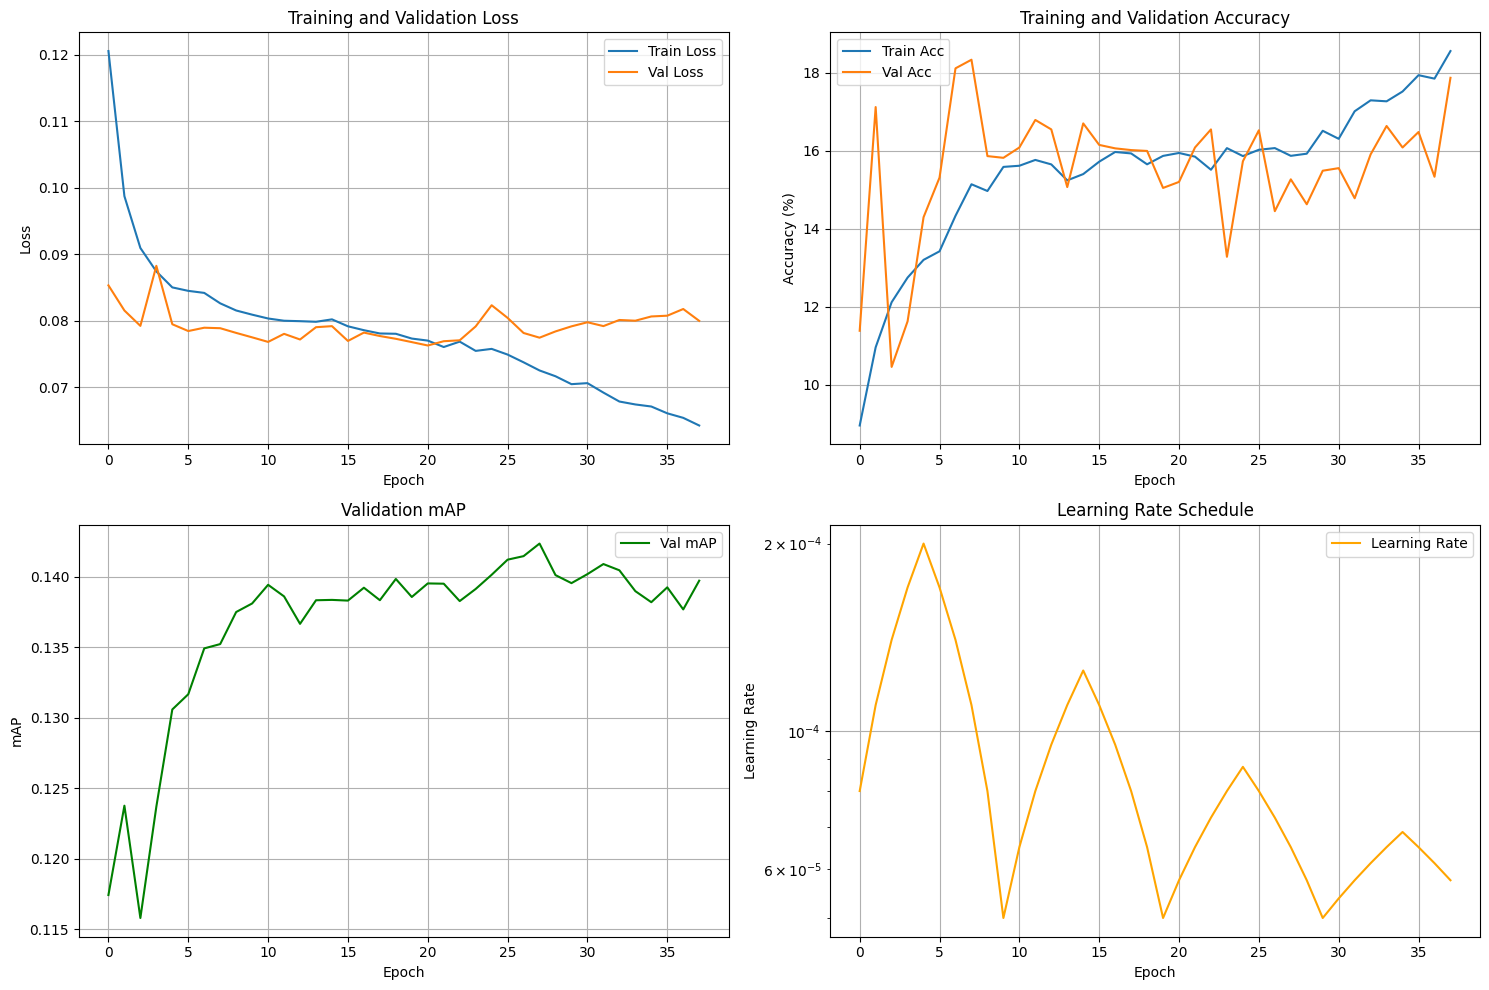

In [ ]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Val Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot([x*100 for x in history['train_acc']], label='Train Acc')
    axes[0, 1].plot([x*100 for x in history['val_acc']], label='Val Acc')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(history['val_map'], label='Val mAP', color='green')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mAP')
    axes[1, 0].set_title('Validation mAP')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(history['lr'], label='Learning Rate', color='orange')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

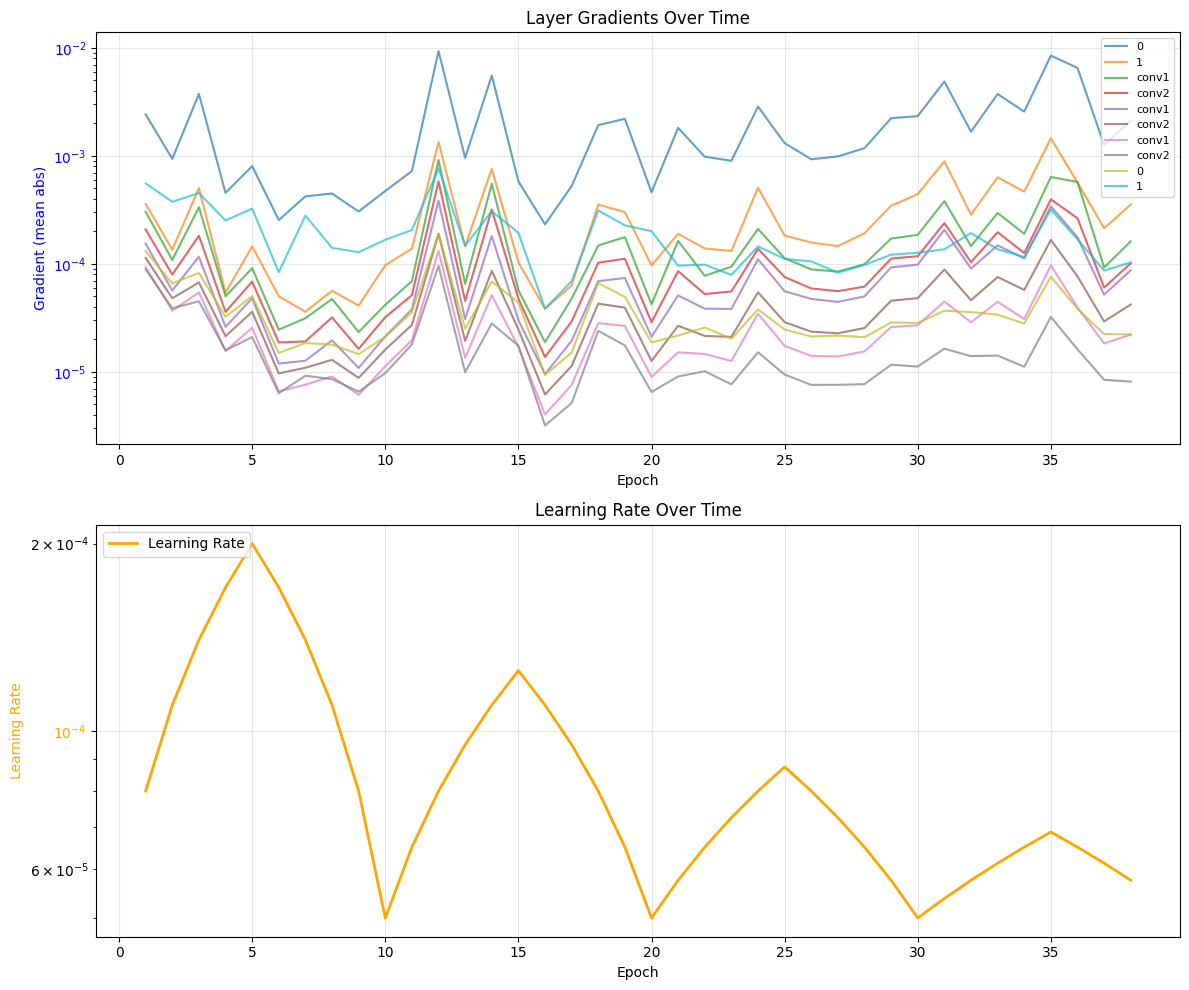

In [ ]:

def plot_gradient_and_lr(history):
    """绘制每层梯度随epoch变化和学习率变化"""
    epochs = range(1, len(history['lr']) + 1)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # 绘制每层的梯度变化
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Gradient (mean abs)', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_title('Layer Gradients Over Time')
    ax1.grid(True, alpha=0.3)

    # 选择一些关键层进行绘制
    key_layers = []
    for layer_name in history['layer_grads'].keys():
        if 'weight' in layer_name and ('conv' in layer_name or 'classifier' in layer_name or 'stem' in layer_name):
            key_layers.append(layer_name)

    if len(key_layers) > 10:
        key_layers = key_layers[:10]

    colors = plt.cm.tab10(np.linspace(0, 1, len(key_layers)))
    for i, layer_name in enumerate(key_layers):
        if layer_name in history['layer_grads']:
            short_name = layer_name.split('.')[-2] if len(layer_name.split('.')) > 2 else layer_name.split('.')[-1]
            ax1.plot(epochs, history['layer_grads'][layer_name],
                    label=short_name, color=colors[i], alpha=0.7, linewidth=1.5)

    ax1.legend(loc='upper right', fontsize=8)
    ax1.set_yscale('log')

    # 绘制学习率变化
    ax2.plot(epochs, history['lr'], color='orange', linewidth=2, label='Learning Rate')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Learning Rate', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.set_title('Learning Rate Over Time')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig('gradient_lr_evolution.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_gradient_and_lr(history)

### Test


Training Complete!
Best Validation Results:
  mAP: 0.1352
  Accuracy: 18.34%
  Loss: 0.0789

Loading best model for test evaluation...
Loaded model from epoch 8
  Validation mAP: 0.1352
  Validation Acc: 18.34%



Evaluating on Test Set: 100%|██████████| 40/40 [00:00<00:00, 115.80it/s, Loss=0.5905, Acc=4.1%]



TEST SET EVALUATION RESULTS
Overall Loss: 0.0895
Overall Accuracy: 19.42%
Total Samples: 5,041

✓ Confusion matrix saved to 'confusion_matrix.png'


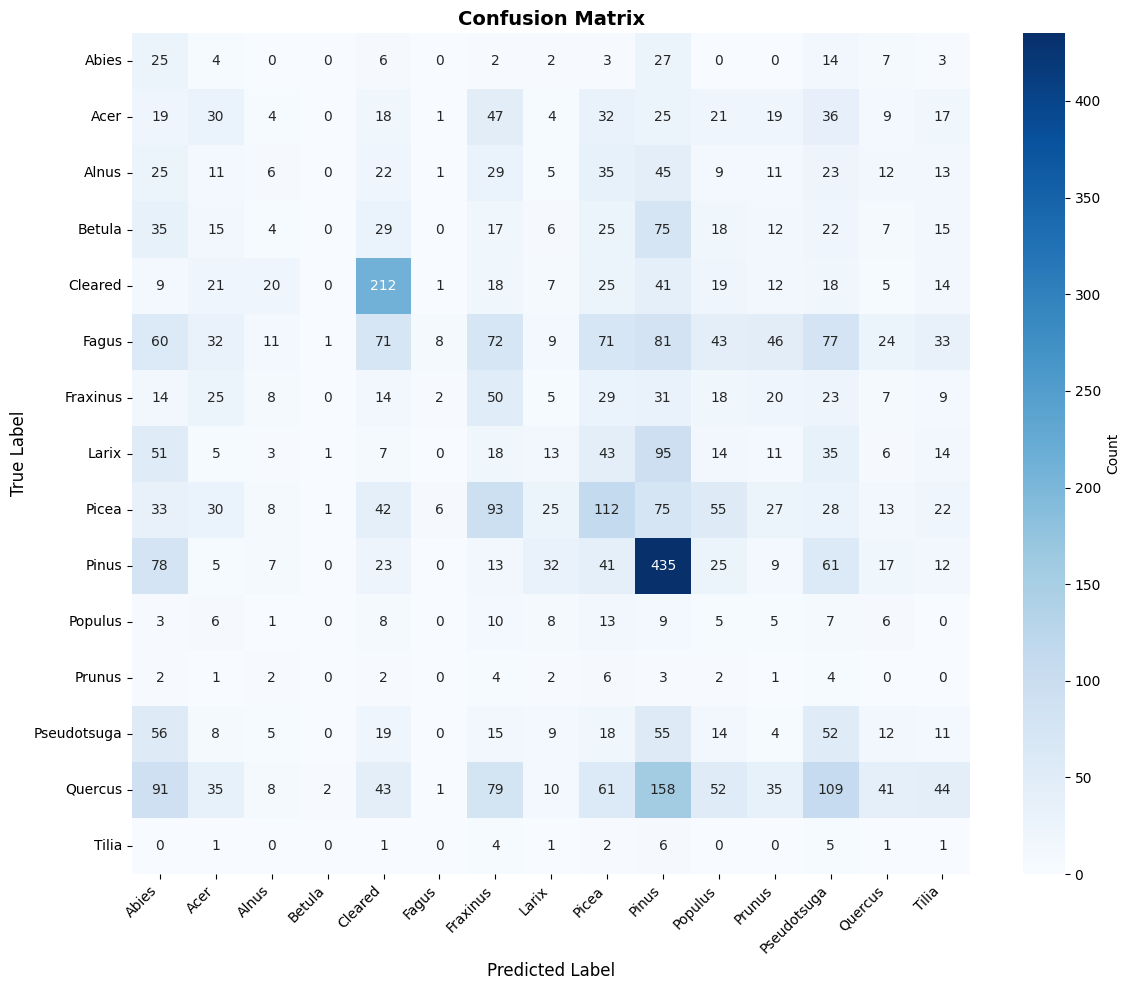


SKLEARN CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Abies       0.05      0.27      0.08        93
        Acer       0.13      0.11      0.12       282
       Alnus       0.07      0.02      0.04       247
      Betula       0.00      0.00      0.00       280
     Cleared       0.41      0.50      0.45       422
       Fagus       0.40      0.01      0.02       639
    Fraxinus       0.11      0.20      0.14       255
       Larix       0.09      0.04      0.06       316
       Picea       0.22      0.20      0.21       570
       Pinus       0.37      0.57      0.45       758
     Populus       0.02      0.06      0.03        81
      Prunus       0.00      0.03      0.01        29
 Pseudotsuga       0.10      0.19      0.13       278
     Quercus       0.25      0.05      0.09       769
       Tilia       0.00      0.05      0.01        22

    accuracy                           0.20      5041
   macro avg       0.15      0.15      0.12      

In [ ]:
print(f"\n{'='*70}")
print("Training Complete!")
print(f"{'='*70}")
print(f"Best Validation Results:")
print(f"  mAP: {best_val_map:.4f}")
print(f"  Accuracy: {best_val_acc*100:.2f}%")
print(f"  Loss: {best_val_loss:.4f}")
print(f"{'='*70}\n")

"""### Test Evaluation with Per-Class Analysis"""

def evaluate_with_per_class_analysis(model, loader, criterion, device, label_mapping=None):
    """
    Comprehensive evaluation with per-class analysis and confusion matrix
    """
    model.eval()
    total_loss = 0
    total_acc = 0
    n_batches = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating on Test Set")
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            output = model(data)

            loss = criterion(output, target)
            acc = compute_accuracy(output, target)

            total_loss += loss.item()
            total_acc += acc
            n_batches += 1

            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{acc*100:.1f}%'
            })

    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Get label names
    if label_mapping and 'idx_to_label' in label_mapping:
        idx_to_label = label_mapping['idx_to_label']
        if isinstance(list(idx_to_label.keys())[0], str):
            idx_to_label = {int(k): v for k, v in idx_to_label.items()}
        target_names = [idx_to_label.get(i, f'Class_{i}') for i in range(len(idx_to_label))]
    else:
        target_names = None

    # === Print Overall Results ===
    print(f"\n{'='*70}")
    print(f"TEST SET EVALUATION RESULTS")
    print(f"{'='*70}")
    print(f"Overall Loss: {avg_loss:.4f}")
    print(f"Overall Accuracy: {avg_acc*100:.2f}%")
    print(f"Total Samples: {len(all_labels):,}")

    # === Confusion Matrix ===
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names if target_names else 'auto',
                yticklabels=target_names if target_names else 'auto',
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    if target_names:
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Confusion matrix saved to 'confusion_matrix.png'")
    plt.show()

    # === Classification Report ===
    print(f"\n{'='*70}")
    print("SKLEARN CLASSIFICATION REPORT")
    print(f"{'='*70}")
    print(classification_report(all_labels, all_preds,
                                target_names=target_names,
                                zero_division=0))

    # === Per-Class Analysis ===
    class_acc = cm.diagonal() / cm.sum(axis=1)
    class_counts = cm.sum(axis=1)
    pred_counts = cm.sum(axis=0)

    print(f"\n{'='*70}")
    print("PER-CLASS DETAILED ANALYSIS")
    print(f"{'='*70}")
    print(f"{'Class':<20} {'Accuracy':>10} {'True':>8} {'Pred':>8} {'Correct':>8}")
    print(f"{'-'*70}")

    for i in range(len(class_acc)):
        label_name = target_names[i] if target_names else f'Class_{i}'
        true_count = int(class_counts[i])
        pred_count = int(pred_counts[i])
        correct_count = int(cm[i, i])
        accuracy = class_acc[i] * 100

        print(f"{label_name:<20} {accuracy:>9.2f}% {true_count:>8} {pred_count:>8} {correct_count:>8}")

    # === Summary Statistics ===
    print(f"\n{'='*70}")
    print("SUMMARY STATISTICS")
    print(f"{'='*70}")
    print(f"Overall Accuracy:      {avg_acc*100:.2f}%")
    print(f"Mean Per-Class Acc:    {class_acc.mean()*100:.2f}%")
    print(f"Std Per-Class Acc:     {class_acc.std()*100:.2f}%")

    if target_names:
        best_idx = class_acc.argmax()
        worst_idx = class_acc.argmin()
        print(f"\nBest Performing Class:  {target_names[best_idx]:<20} ({class_acc[best_idx]*100:.2f}%)")
        print(f"Worst Performing Class: {target_names[worst_idx]:<20} ({class_acc[worst_idx]*100:.2f}%)")

    # === Check for Issues ===
    unique_preds = set(all_preds)
    unique_labels = set(all_labels)
    never_predicted = unique_labels - unique_preds

    if never_predicted:
        print(f"\n⚠️ WARNING: Classes never predicted: {sorted(never_predicted)}")
        if target_names:
            never_pred_names = [target_names[i] for i in sorted(never_predicted)]
            print(f"   Labels: {', '.join(never_pred_names)}")

    # Classes with very low accuracy (<20%)
    low_acc_classes = [(i, class_acc[i]) for i in range(len(class_acc)) if class_acc[i] < 0.2]
    if low_acc_classes:
        print(f"\n⚠️ WARNING: {len(low_acc_classes)} class(es) with accuracy < 20%:")
        for idx, acc in low_acc_classes:
            label_name = target_names[idx] if target_names else f'Class_{idx}'
            print(f"   {label_name}: {acc*100:.2f}%")

    print(f"\n{'='*70}\n")

    return avg_loss, avg_acc, all_preds, all_labels, cm

# === Load Best Model and Evaluate ===
print("Loading best model for test evaluation...")
checkpoint = torch.load('best_classification_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1}")
print(f"  Validation mAP: {checkpoint['val_map']:.4f}")
print(f"  Validation Acc: {checkpoint['val_acc']*100:.2f}%\n")

test_loss, test_acc, test_preds, test_labels, test_cm = evaluate_with_per_class_analysis(
    model, test_loader, criterion, device, label_mapping=label_mapping
)



# New

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import h5py
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
import json
from sklearn.metrics import (classification_report, average_precision_score,
                            confusion_matrix)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/data/"

Using device: cuda
Mounted at /content/drive


### Data Preprocessing

In [ ]:
def load_label_mapping(mapping_path):
    with open(mapping_path, 'r') as f:
        mapping = json.load(f)
    print(f"classes: {mapping['n_classes']}")
    print(f"labels: {list(mapping['label_to_idx'].items())[:]}")
    return mapping

label_mapping = load_label_mapping(BASE_DIR+'label_mapping.json')
n_classes = label_mapping['n_classes']

classes: 15
labels: [('Abies', 0), ('Acer', 1), ('Alnus', 2), ('Betula', 3), ('Cleared', 4), ('Fagus', 5), ('Fraxinus', 6), ('Larix', 7), ('Picea', 8), ('Pinus', 9), ('Populus', 10), ('Prunus', 11), ('Pseudotsuga', 12), ('Quercus', 13), ('Tilia', 14)]


### Dataloader / Augmentation

In [ ]:
class H5Dataset(Dataset):
    def __init__(self, h5_path: str):
        self.h5f = h5py.File(h5_path, 'r')
        self.images = self.h5f['images']
        self.labels = self.h5f['labels']
        self.valid_indices = self._filter_nan_samples()
        self.n_samples = len(self.valid_indices)
        print(f"H5Dataset initialized: {h5_path}")
        print(f"Total samples: {len(self.labels)}")
        print(f"Valid samples: {self.n_samples}")

    def _filter_nan_samples(self):
        valid_indices = []
        for idx in range(len(self.h5f['labels'])):
            img = self.images[idx].astype(np.float32)
            input_bands = img[1:3]  # VV, VH
            if not np.isnan(input_bands).any():
                valid_indices.append(idx)
        return valid_indices

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        img = self.images[actual_idx].astype(np.float32).copy()
        input_bands = img[1:3]  # VV, VH
        label = int(self.labels[actual_idx])

        vv = torch.from_numpy(input_bands[0])  # [H, W]
        vh = torch.from_numpy(input_bands[1])  # [H, W]
        image = torch.stack([vv, vh], dim=0)   # [2, H, W]

        label = torch.tensor(label, dtype=torch.long)
        return image, label

    def get_filename(self, idx):
        actual_idx = self.valid_indices[idx]
        return self.images.file['filenames'][actual_idx].decode('utf-8')

    def get_label_name(self, idx):
        actual_idx = self.valid_indices[idx]
        return self.images.file['label_names'][actual_idx].decode('utf-8')

    def close(self):
        if hasattr(self, 'h5f'):
            self.h5f.close()

    def __del__(self):
        self.close()

def create_dataloaders(
    train_h5: str,
    test_h5: str,
    batch_size: int = 128,
    num_workers: int = 4,
    val_ratio: float = 0.1
):
    train_dataset = H5Dataset(train_h5)
    test_dataset = H5Dataset(test_h5)

    original_train_size = len(train_dataset)
    val_size = int(original_train_size * val_ratio)
    train_size = original_train_size - val_size

    torch.manual_seed(42)
    train_indices, val_indices = random_split(
        range(original_train_size),
        [train_size, val_size]
    )

    train_subset = torch.utils.data.Subset(train_dataset, train_indices.indices)
    val_dataset = torch.utils.data.Subset(train_dataset, val_indices.indices)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    return train_loader, val_loader, test_loader, train_dataset

In [ ]:
batch_size = 128
train_loader, val_loader, test_loader, full_train_dataset = create_dataloaders(
    train_h5=BASE_DIR + 'train_data.h5',
    test_h5=BASE_DIR + 'test_data.h5',
    batch_size=128,
    num_workers=4,
    val_ratio=0.2
)

H5Dataset initialized: /content/drive/MyDrive/data/train_data.h5
Total samples: 45337
Valid samples: 45314
H5Dataset initialized: /content/drive/MyDrive/data/test_data.h5
Total samples: 5044
Valid samples: 5041


### UNet++ Model

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels, momentum=0.01),
            nn.GELU(),
            nn.Dropout2d(dropout),

            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels, momentum=0.01),
            nn.GELU()
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:

class UNetPlusPlus(nn.Module):
    """
    UNet++ for classification tasks(Nested skip connection), adapted for 6×6 small patches
    Input: (B, 2, 6, 6)
    Output: (B, 15)
    Only two pooling layers are possible
    """

    def __init__(self, in_channels=2, num_classes=15, base_channels=32, dropout=0.3):
        super().__init__()

        # configure the number of channels
        nb_filter = [base_channels, base_channels*2, base_channels*4]
        self.pool = nn.MaxPool2d(2, 2)

        self.conv0_0 = ConvBlock(in_channels, nb_filter[0], dropout)
        self.conv1_0 = ConvBlock(nb_filter[0], nb_filter[1], dropout)
        self.conv0_1 = ConvBlock(nb_filter[0] + nb_filter[1], nb_filter[0], dropout)
        self.conv2_0 = ConvBlock(nb_filter[1], nb_filter[2], dropout)
        self.conv1_1 = ConvBlock(nb_filter[1] + nb_filter[2], nb_filter[1], dropout)
        self.conv0_2 = ConvBlock(nb_filter[0]*2 + nb_filter[1], nb_filter[0], dropout)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(nb_filter[0] * 2 + nb_filter[2], base_channels * 4),  # 融合3个输出
            nn.BatchNorm1d(base_channels * 4, momentum=0.01),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(base_channels * 4, base_channels * 2),
            nn.BatchNorm1d(base_channels * 2, momentum=0.01),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),

            nn.Linear(base_channels * 2, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # encoder
        x0_0 = self.conv0_0(x)  # (B, 32, 6, 6)
        x1_0 = self.conv1_0(self.pool(x0_0))  # (B, 64, 3, 3)

        # nested nodes
        x0_1 = self.conv0_1(torch.cat([x0_0, F.interpolate(x1_0, size=x0_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 32, 6, 6)

        # bottleneck
        x2_0 = self.conv2_0(self.pool(x1_0))  # (B, 128, 1, 1)

        # decoder
        x1_1 = self.conv1_1(torch.cat([x1_0, F.interpolate(x2_0, size=x1_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 64, 3, 3)
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, F.interpolate(x1_1, size=x0_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 32, 6, 6)

        # deep supervision, feature fusion
        out0_1 = self.global_pool(x0_1).flatten(1)  # (B, 32)
        out0_2 = self.global_pool(x0_2).flatten(1)  # (B, 32)
        out_bottleneck = self.global_pool(x2_0).flatten(1)  # (B, 128)

        multi_scale_features = torch.cat([
            out0_1, out0_2, out_bottleneck
        ], dim=1)  # (B, 32+32+128) = (B, 192)

        # clf
        logits = self.classifier(multi_scale_features)

        return logits

### Loss

In [ ]:
class PseudoHuberLoss(nn.Module):
    def __init__(self, delta=1.0, alpha=None):
        super(PseudoHuberLoss, self).__init__()
        self.delta = delta

        if alpha is None:
            self.alpha = None
        elif isinstance(alpha, (float, int)):
            self.alpha = torch.tensor([alpha])
        else:
            self.alpha = alpha if isinstance(alpha, torch.Tensor) else torch.tensor(alpha)

    def forward(self, inputs, targets):
        """
        inputs: [B, C] logits
        targets: [B] class indices
        """
        # 先计算交叉熵作为基础误差
        ce_loss = F.cross_entropy(inputs, targets)  # [B]

        # 应用Pseudo-Huber变换: δ² * (√(1 + (x/δ)²) - 1)
        delta_sq = self.delta ** 2
        normalized_loss = ce_loss / self.delta
        ph_loss = delta_sq * (torch.sqrt(1 + normalized_loss ** 2) - 1)

        # 应用类别权重
        if self.alpha is not None:
            if self.alpha.device != inputs.device:
                self.alpha = self.alpha.to(inputs.device)
            alpha_t = self.alpha[targets]
            ph_loss = alpha_t * ph_loss

        # 应用reduction
        return ph_loss.mean()

In [ ]:
def compute_class_weights(dataloader, num_classes, method='inverse', beta=0.9999):
    class_counts = torch.zeros(num_classes, dtype=torch.long)

    for _, labels in tqdm(dataloader, desc="Counting labels"):
        for label in labels:
            class_counts[label.item()] += 1

    total_samples = class_counts.sum().item()

    if method == 'inverse':
        weights = 1.0 / class_counts.float()
    elif method == 'balanced':
        weights = total_samples / (num_classes * class_counts.float())
    elif method == 'effective':
        effective_num = 1.0 - torch.pow(beta, class_counts.float())
        weights = (1.0 - beta) / effective_num
    else:
        raise ValueError(f"Unknown method: {method}")

    weights = weights / weights.mean()
    return weights

### Function

In [ ]:
def compute_accuracy(pred, target):
    pred_labels = torch.argmax(pred, dim=1)  # [B]
    correct = (pred_labels == target).float()  # [B]
    total = target.size(0)
    accuracy = correct.sum().item() / total if total > 0 else 0.0
    return accuracy

def compute_map(pred, target, num_classes):
    probs = torch.softmax(pred, dim=1).cpu().numpy()  # [B, num_classes]
    target_np = target.cpu().numpy()  # [B]
    if len(target_np) == 0:
        return 0.0
    target_onehot = np.eye(num_classes)[target_np]  # [B, num_classes]
    aps = []
    for i in range(num_classes):
        if target_onehot[:, i].sum() > 0:
            try:
                ap = average_precision_score(target_onehot[:, i], probs[:, i])
                aps.append(ap)
            except:
                continue
    return np.mean(aps) if len(aps) > 0 else 0.0

def train_classification_paper(model, train_dataset, criterion, optimizer, scheduler, device, epoch,
                               steps_per_epoch=50, total_batches=None):
    """
    Training function according to paper specifications:
    - Random batch selection
    - Fixed steps per epoch
    """
    model.train()
    total_loss = 0
    total_acc = 0
    n_batches = 0

    # Create indices for random batch selection
    total_samples = len(train_dataset)
    batch_size = 128

    pbar = tqdm(range(steps_per_epoch), desc=f"Epoch {epoch+1}")

    for step in pbar:
        # Randomly select batch indices
        indices = torch.randint(0, total_samples, (batch_size,))

        # Get batch data
        batch_data = []
        batch_labels = []
        for idx in indices:
            data, label = train_dataset[idx.item()]
            batch_data.append(data)
            batch_labels.append(label)

        data = torch.stack(batch_data).to(device)
        target = torch.stack(batch_labels).to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        with torch.no_grad():
            acc = compute_accuracy(output, target)

        total_loss += loss.item()
        total_acc += acc
        n_batches += 1

        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{acc*100:.1f}%'
        })

    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches

    return avg_loss, avg_acc

def evaluate_classification(model, loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")
        for batch_data in pbar:
            data, target = batch_data
            data = data.to(device)
            target = target.to(device)

            # 前向传播
            output = model(data)
            loss = criterion(output, target)

            # 计算准确率
            pred = output.argmax(dim=1)
            correct = (pred == target).sum().item()
            batch_acc = correct / target.size(0)

            # 累积统计
            total_loss += loss.item() * target.size(0)
            total_correct += correct
            total_samples += target.size(0)

            # 存储预测结果
            all_preds.append(output.detach().cpu())
            all_targets.append(target.cpu())

            # 更新进度条
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{batch_acc*100:.1f}%'
            })

    # 计算平均指标
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    # 合并所有预测
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    # 计算 mAP
    mAP = compute_map(all_preds, all_targets, num_classes)

    return avg_loss, avg_acc, mAP

### Train

In [ ]:
# Compute class weights
class_weights = compute_class_weights(
    train_loader,
    num_classes=n_classes,
    method='inverse',
    beta=0.9
)

Counting labels: 100%|██████████| 284/284 [00:01<00:00, 257.80it/s]


In [ ]:
# Initialize UNet++ model
model = UNetPlusPlus(in_channels=2, num_classes=n_classes, base_channels=32, dropout=0.3).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 552,399
Trainable parameters: 552,399


In [ ]:
# Pseudo-Huber Loss with class weights
criterion = PseudoHuberLoss(delta=0.1, alpha=class_weights)

# Adam optimizer with low learning rate (as per paper)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,  # Low learning rate as specified in paper
    weight_decay=1e-4  # Weight regularization to reduce overfitting
)

In [ ]:
# Paper specifications:
# - 5,000 epochs
# - 50 steps per epoch
# - Reduce LR by 10% every 100 epochs when plateau is reached
num_epochs = 5000
steps_per_epoch = 50

# Learning rate scheduler: reduce by 10% every 100 epochs on plateau
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.9,  # Reduce by 10%
    patience=100,  # Wait 100 epochs before reducing
    min_lr=1e-7
)

best_val_loss = float('inf')
best_val_acc = 0.0
best_val_map = 0.0
patience_counter = 0
early_stop_patience = 500  # Increased for long training

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_map': [], 'lr': []
}

print(f"Model: UNet++")
print(f"Epochs: {num_epochs}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Batch size: 128")
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']:.2e}")
print(f"LR reduction: 10% every 100 epochs on plateau")
print(f"Loss: Pseudo-Huber (delta=0.1)")
print(f"Optimizer: Adam with weight decay={optimizer.param_groups[0]['weight_decay']}")

Model: UNet++
Epochs: 5000
Steps per epoch: 50
Batch size: 128
Initial learning rate: 1.00e-04
LR reduction: 10% every 100 epochs on plateau
Loss: Pseudo-Huber (delta=0.1)
Optimizer: Adam with weight decay=0.0001


In [ ]:
for epoch in range(num_epochs):
    train_loss, train_acc = train_classification_paper(
        model, full_train_dataset, criterion, optimizer, scheduler, device, epoch,
        steps_per_epoch=steps_per_epoch
    )
    val_loss, val_acc, val_map = evaluate_classification(
        model, val_loader, criterion, device, n_classes
    )

    # Update learning rate based on validation loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_map'].append(val_map)
    history['lr'].append(current_lr)

    # Print every 10 epochs to reduce output
    if (epoch + 1) % 10 == 0 or epoch < 10:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}% | Val mAP: {val_map:.4f} | LR: {current_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_map = val_map
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_map': val_map,
            'history': history
        }, 'best_unetpp_model.pth')

        if (epoch + 1) % 10 == 0 or epoch < 10:
            print(f" *Best model | mAP: {best_val_map:.4f}, Acc: {best_val_acc*100:.2f}%, Loss: {best_val_loss:.4f}\n")
    else:
        patience_counter += 1
        if (epoch + 1) % 10 == 0 or epoch < 10:
            print(f"Patience: {patience_counter}/{early_stop_patience}\n")

    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Evaluating: 100%|██████████| 71/71 [00:00<00:00, 108.17it/s, Loss=0.0667, Acc=5.9%]


Epoch 1/5000
  Train Loss: 0.1204 | Train Acc: 6.44%
  Val Loss:   0.0838 | Val Acc:   7.28% | Val mAP: 0.0833 | LR: 1.00e-04
 *Best model | mAP: 0.0833, Acc: 7.28%, Loss: 0.0838



Evaluating: 100%|██████████| 71/71 [00:00<00:00, 113.11it/s, Loss=0.0657, Acc=6.9%]


Epoch 2/5000
  Train Loss: 0.1213 | Train Acc: 6.41%
  Val Loss:   0.0816 | Val Acc:   7.26% | Val mAP: 0.0874 | LR: 1.00e-04
Patience: 1/500



Evaluating: 100%|██████████| 71/71 [00:00<00:00, 111.11it/s, Loss=0.0655, Acc=7.8%]


...

Epoch 4980/5000
  Train Loss: 0.0489 | Train Acc: 25.81%
  Val Loss:   0.0446 | Val Acc:   31.19% | Val mAP: 0.4572 | LR: 5.31e-05
 *Best model | mAP: 0.4572, Acc: 31.19%, Loss: 0.0446



Evaluating: 100%|██████████| 71/71 [00:00<00:00, 105.32it/s, Loss=0.0443, Acc=23.5%]


Epoch 4990/5000
  Train Loss: 0.0492 | Train Acc: 26.81%
  Val Loss:   0.0449 | Val Acc:   29.75% | Val mAP: 0.4551 | LR: 5.31e-05
Patience: 10/500



Evaluating: 100%|██████████| 71/71 [00:00<00:00, 104.84it/s, Loss=0.0434, Acc=24.5%]


Epoch 5000/5000
  Train Loss: 0.0494 | Train Acc: 25.33%
  Val Loss:   0.0447 | Val Acc:   29.87% | Val mAP: 0.4570 | LR: 5.31e-05
Patience: 20/500



### *** Quick Check

In [ ]:
print(f"Best Validation Results:")
print(f"  mAP: {best_val_map:.4f}")
print(f"  Accuracy: {best_val_acc*100:.2f}%")
print(f"  Loss: {best_val_loss:.4f}")

Best Validation Results:
  mAP: 0.4572
  Accuracy: 31.19%
  Loss: 0.0446


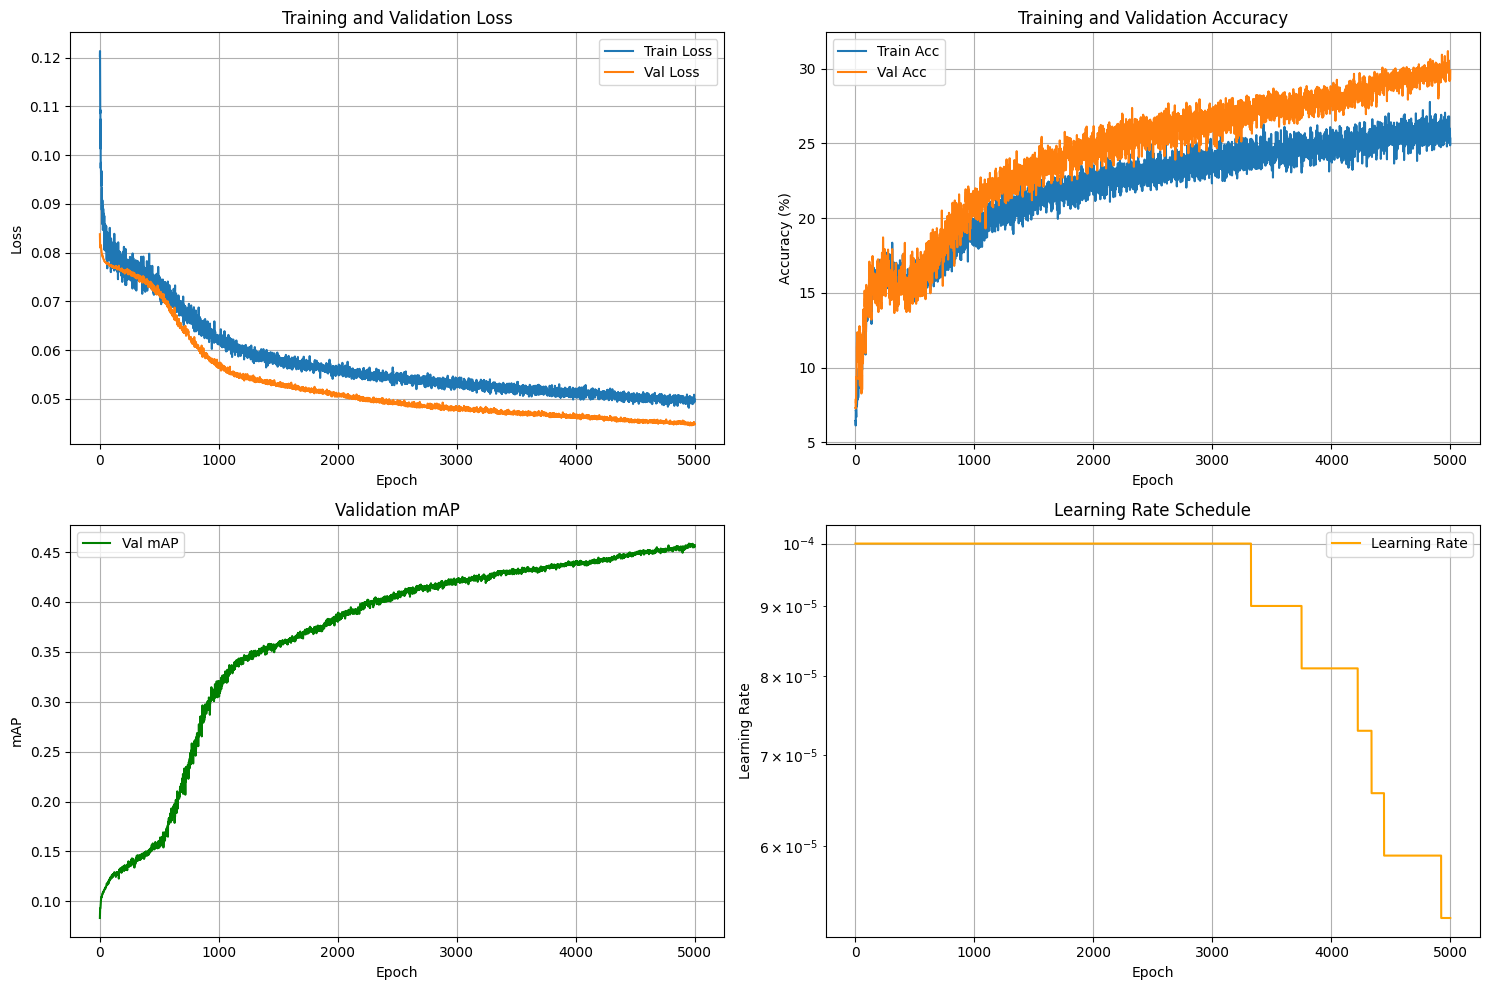

In [ ]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Val Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot([x*100 for x in history['train_acc']], label='Train Acc')
    axes[0, 1].plot([x*100 for x in history['val_acc']], label='Val Acc')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(history['val_map'], label='Val mAP', color='green')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mAP')
    axes[1, 0].set_title('Validation mAP')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(history['lr'], label='Learning Rate', color='orange')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig('training_history_unetpp.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

### Test

In [ ]:
def evaluate_with_per_class_analysis(model, loader, criterion, device, label_mapping=None):
    """
    Comprehensive evaluation with per-class analysis and confusion matrix
    """
    model.eval()
    total_loss = 0
    total_acc = 0
    n_batches = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating on Test Set")
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            output = model(data)

            loss = criterion(output, target)
            acc = compute_accuracy(output, target)

            total_loss += loss.item()
            total_acc += acc
            n_batches += 1

            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{acc*100:.1f}%'
            })

    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Get label names
    if label_mapping and 'idx_to_label' in label_mapping:
        idx_to_label = label_mapping['idx_to_label']
        if isinstance(list(idx_to_label.keys())[0], str):
            idx_to_label = {int(k): v for k, v in idx_to_label.items()}
        target_names = [idx_to_label.get(i, f'Class_{i}') for i in range(len(idx_to_label))]
    else:
        target_names = None

    print(f"Test dataset results:")
    print(f"  Overall Loss: {avg_loss:.4f}")
    print(f"  Overall Accuracy: {avg_acc*100:.2f}%")
    print(f"  Total Samples: {len(all_labels):,}")

    """
    Confusion Matrix
    """
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names if target_names else 'auto',
                yticklabels=target_names if target_names else 'auto',
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - UNet++', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    if target_names:
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    """
    sklearn classification report
    """
    print("sklearn classification report:")
    print(classification_report(all_labels, all_preds,
                                target_names=target_names,
                                zero_division=0))

    """
    per-class analysis
    """
    class_acc = cm.diagonal() / cm.sum(axis=1)
    class_counts = cm.sum(axis=1)
    pred_counts = cm.sum(axis=0)

    print(f"{'Class':<20} {'Accuracy':>10} {'True':>8} {'Pred':>8} {'Correct':>8}")

    for i in range(len(class_acc)):
        label_name = target_names[i] if target_names else f'Class_{i}'
        true_count = int(class_counts[i])
        pred_count = int(pred_counts[i])
        correct_count = int(cm[i, i])
        accuracy = class_acc[i] * 100

        print(f"{label_name:<20} {accuracy:>9.2f}% {true_count:>8} {pred_count:>8} {correct_count:>8}")

    print("Summary:")
    print(f"  Overall Accuracy:      {avg_acc*100:.2f}%")
    print(f"  Mean Per-Class Acc:    {class_acc.mean()*100:.2f}%")
    print(f"  Std Per-Class Acc:     {class_acc.std()*100:.2f}%")

    if target_names:
        best_idx = class_acc.argmax()
        worst_idx = class_acc.argmin()
        print(f"\nBest Performing Class:  {target_names[best_idx]:<20} ({class_acc[best_idx]*100:.2f}%)")
        print(f"Worst Performing Class: {target_names[worst_idx]:<20} ({class_acc[worst_idx]*100:.2f}%)")

    return avg_loss, avg_acc, all_preds, all_labels, cm

Loading best model for test evaluation...
Loaded model from epoch 4980
  Validation mAP: 0.4572
  Validation Loss: 0.0446
  Validation Acc: 31.19%



Evaluating on Test Set: 100%|██████████| 40/40 [00:00<00:00, 81.93it/s, Loss=1.3879, Acc=4.1%]


Test dataset results:
  Overall Loss: 0.1258
  Overall Accuracy: 20.59%
  Total Samples: 5,041


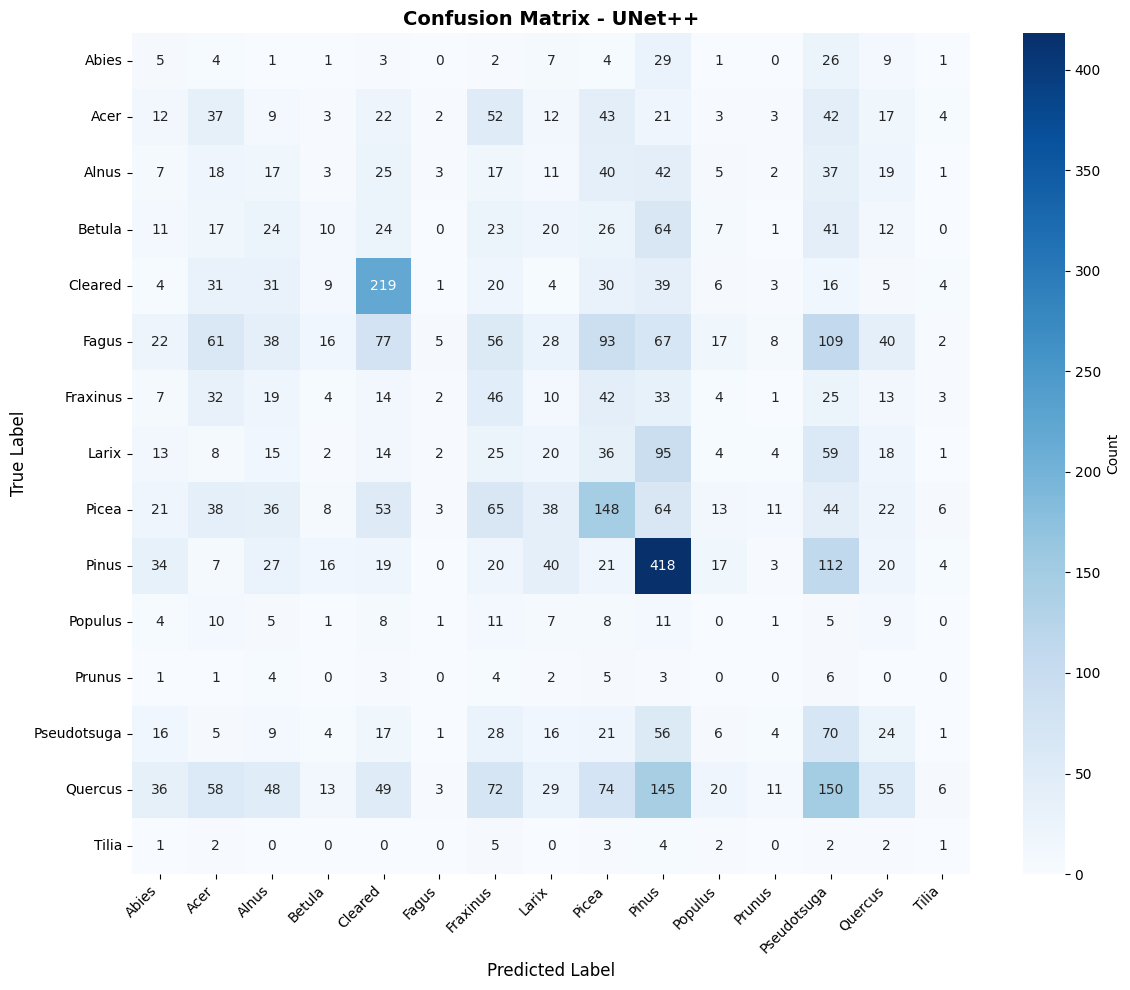

sklearn classification report:
              precision    recall  f1-score   support

       Abies       0.03      0.05      0.03        93
        Acer       0.11      0.13      0.12       282
       Alnus       0.06      0.07      0.06       247
      Betula       0.11      0.04      0.05       280
     Cleared       0.40      0.52      0.45       422
       Fagus       0.22      0.01      0.02       639
    Fraxinus       0.10      0.18      0.13       255
       Larix       0.08      0.06      0.07       316
       Picea       0.25      0.26      0.25       570
       Pinus       0.38      0.55      0.45       758
     Populus       0.00      0.00      0.00        81
      Prunus       0.00      0.00      0.00        29
 Pseudotsuga       0.09      0.25      0.14       278
     Quercus       0.21      0.07      0.11       769
       Tilia       0.03      0.05      0.04        22

    accuracy                           0.21      5041
   macro avg       0.14      0.15      0.13      

In [ ]:
# === Load Best Model and Evaluate ===
print("Loading best model for test evaluation...")
checkpoint = torch.load('best_unetpp_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1}")
print(f"  Validation mAP: {checkpoint['val_map']:.4f}")
print(f"  Validation Loss: {checkpoint['val_loss']:.4f}")
print(f"  Validation Acc: {checkpoint['val_acc']*100:.2f}%\n")

test_loss, test_acc, test_preds, test_labels, test_cm = evaluate_with_per_class_analysis(
    model, test_loader, criterion, device, label_mapping=label_mapping
)